Iteration: 1 | Average total: -4 | Last total: -200.
Iteration: 51 | Average total: -200 | Last total: -200.
Iteration: 101 | Average total: -200 | Last total: -200.
Iteration: 151 | Average total: -200 | Last total: -200.
Iteration: 201 | Average total: -200 | Last total: -200.
Iteration: 251 | Average total: -200 | Last total: -200.
Iteration: 301 | Average total: -200 | Last total: -200.
Iteration: 351 | Average total: -200 | Last total: -200.
Iteration: 401 | Average total: -200 | Last total: -200.
Iteration: 451 | Average total: -200 | Last total: -200.
Iteration: 501 | Average total: -200 | Last total: -200.
Iteration: 551 | Average total: -200 | Last total: -200.
Iteration: 601 | Average total: -200 | Last total: -200.
Iteration: 651 | Average total: -200 | Last total: -200.
Iteration: 701 | Average total: -200 | Last total: -200.
Iteration: 751 | Average total: -200 | Last total: -200.
Iteration: 801 | Average total: -200 | Last total: -200.
Iteration: 851 | Average total: -200

-124.0

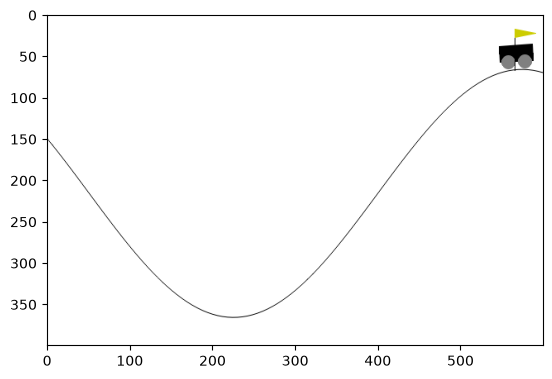

In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

def observation_to_state(env, obs, states = (40,40)):
    """
    Convert observation from environment into a discrete state.
    
    Parameters
    ----------
    env : gym env
        Reference to the current environment.
    obs : tuple or array 
        An observation for the agent.
    states : tuple, optional
        For each dimension, the number of bins used. The default is (40,40).

    Returns
    -------
    A tuple containing the state corresponding to the observation.

    """    
    ##
    ## your code here
    ##
    obs_high = env.observation_space.high
    obs_low = env.observation_space.low
    dx = (obs_high - obs_low) / states # the width of each bins 
    # the current bin of our car
    s0 = int((obs[0] - obs_low[0])/dx[0]) # the x axis 
    s1 = int((obs[1] - obs_low[1]) /dx[1]) # the y axis 
    return s0, s1


### RL below this line
# Q - learning 
def choose(env, q, state, epsilon):
    """
    epsilon-greedy action selection. Greedy action selection if epsilon == 0.

    Parameters
    ----------
    env : gym env
        Reference to the current environment
    q : np.array (state_1 x .. x state_n x actions)
        A (n+1) dimensional q table:
            (n state dimensions + 1 action dimension)
            probability of taking an action
    state : tuple
        2-dimensional integer tuple describing the current state of the agent.
    epsilon : float
        Probability of taking a random action.
        If epsilon == 0, we use (max) greedy action selection.
        If epsilon > 0, we choose epsilon-greedy and according to probability

    Returns
    -------
    int
        The chosen action.

    """
    assert len(q.shape)-1 == len(state), "number of state dimensions in "
    "q-table should match dimensions in state parameter"

    s0, s1 = state
    
    if epsilon == 0:
        # return best action (deterministically)
        return np.argmax(q[s0, s1])
    
    if np.random.uniform(0, 1) < epsilon:
        return np.random.choice(env.action_space.n)

    logits = q[s0, s1]    
    logits_exp = np.exp(logits)
    probabilities = logits_exp / sum(logits_exp)
    
    return np.random.choice(env.action_space.n, p = probabilities)


def qlearn(env, alpha, epsilon, gamma, max_steps,
           num_episodes = 5000, num_states = (40,40)):
    """
    Tabular Q-Learning for gym

    Parameters
    ----------
    env : gym env
        Reference to the current environment
    alpha : float 
        an initial learning rate; reduced for every episode down to a minimum.
    epsilon : float
        a probability for choosing a random action (0 <= epsilon <= 1).
    terminal : list
        a list of terminal states
    gamma : float
        a discount value (0 < gamma < 1).
    num_episodes : int, optional
        Number of episodes to train. The default is 5000.
    num_states : tuple, optional
        Number of states in each observation dimension. The default is (40,40).

    Returns
    -------
    q : array (num_states x num_actions)
        state-action value table.

    """
    q = np.zeros((num_states[0], num_states[1], env.action_space.n))

    avg_reward = 0
    avg_freq = 50
    
    for i in range(num_episodes):
        obs, _ = env.reset()
        total_reward = 0
        eta = max(0.005, alpha * (0.85 ** (i//100)))

        for t in range(max_steps):
            s0, s1 = observation_to_state(env, obs, num_states)
            action = choose(env, q, (s0, s1), epsilon)
            obs, reward, done, truncated, _ = env.step(action)
            total_reward += reward
            avg_reward += reward
            
            s2, s3 = observation_to_state(env, obs, num_states)
            
            q[s0, s1, action] = q[s0, s1, action] + eta * (reward + gamma *  np.max(q[s2,s3]) - q[s0, s1, action])
            if done or truncated:
                break

            s0, s1 = s2, s3

        if i % avg_freq == 0:
            avg_reward /= avg_freq
            print('Iteration: %d | Average total: %d | Last total: %d.' %(i+1, avg_reward, total_reward))
            avg_reward = 0

    return q


def run_policy(env, q, max_steps, num_states = (40,40), render = False):

    obs, _ = env.reset()
    total_reward = 0
    for t in range(max_steps):
        state = observation_to_state(env, obs, num_states)
        action = choose(env, q, state, 0)
        obs, reward, done, truncated, _ = env.step(action)
        if render:
            plt.imshow(env.render())
            
        total_reward += reward
        if done or truncated:
            break
    
    return total_reward


alpha = 1.0
epsilon = 0.05
gamma = 1.0
max_steps = 200
environment = gym.make('MountainCar-v0', render_mode = 'rgb_array')
np.random.seed(0)

q = qlearn(environment, alpha, epsilon, gamma, max_steps)
scores = [run_policy(environment, q, max_steps) for _ in range(100)]
print('Mean score: ', np.mean(scores))

run_policy(environment, q, max_steps, render = True)

Iteration: 1 (Dyna: 5 steps) | Average total: -4 | Last total: -200.
Iteration: 51 (Dyna: 5 steps) | Average total: -200 | Last total: -200.
Iteration: 101 (Dyna: 5 steps) | Average total: -200 | Last total: -200.
Iteration: 151 (Dyna: 5 steps) | Average total: -200 | Last total: -200.
Iteration: 201 (Dyna: 5 steps) | Average total: -200 | Last total: -200.
Iteration: 251 (Dyna: 5 steps) | Average total: -200 | Last total: -200.
Iteration: 301 (Dyna: 5 steps) | Average total: -200 | Last total: -200.
Iteration: 351 (Dyna: 5 steps) | Average total: -200 | Last total: -200.
Iteration: 401 (Dyna: 5 steps) | Average total: -200 | Last total: -200.
Iteration: 451 (Dyna: 5 steps) | Average total: -200 | Last total: -200.
Iteration: 501 (Dyna: 5 steps) | Average total: -200 | Last total: -200.
Iteration: 551 (Dyna: 5 steps) | Average total: -200 | Last total: -200.
Iteration: 601 (Dyna: 5 steps) | Average total: -200 | Last total: -200.
Iteration: 651 (Dyna: 5 steps) | Average total: -200 | L

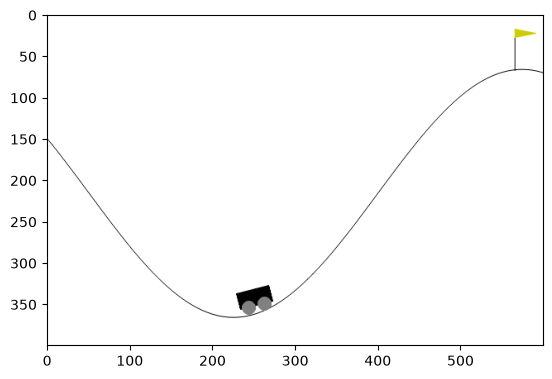

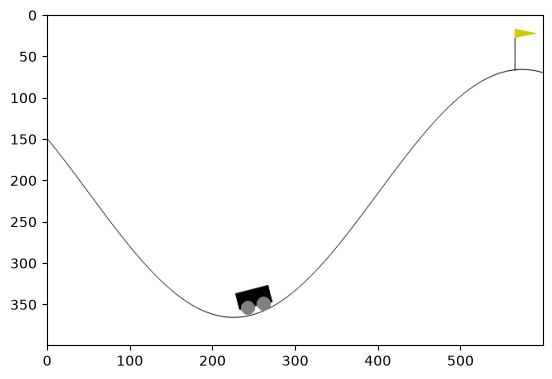

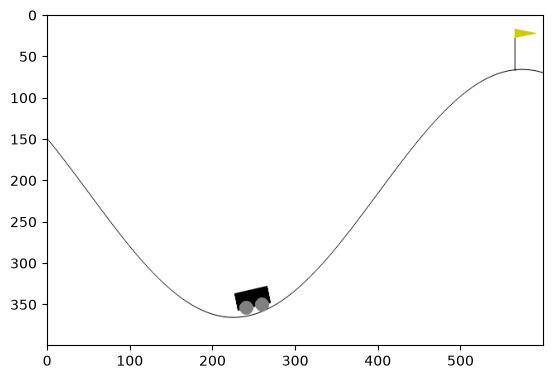

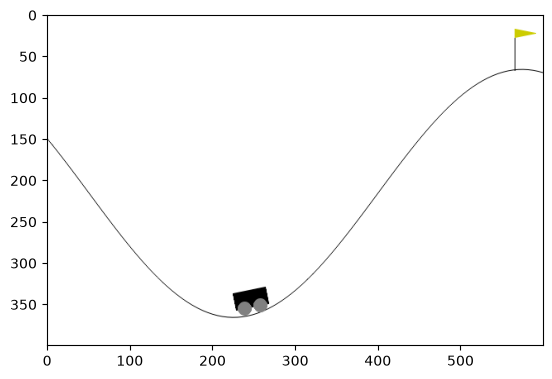

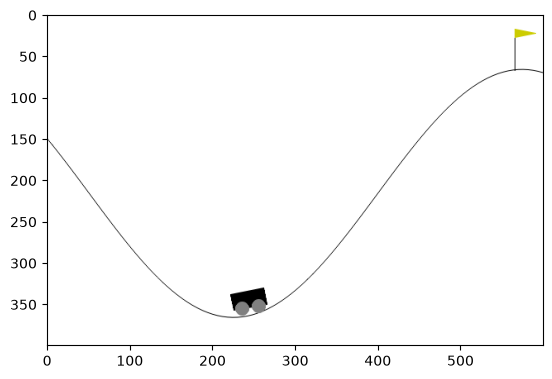

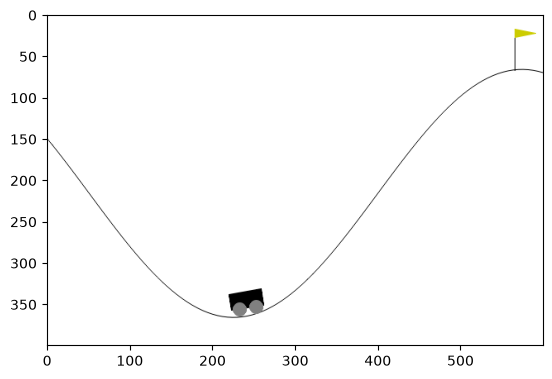

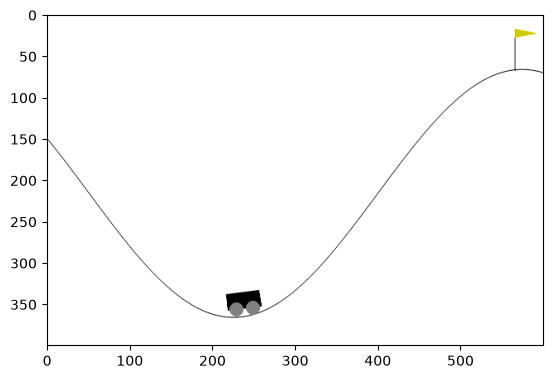

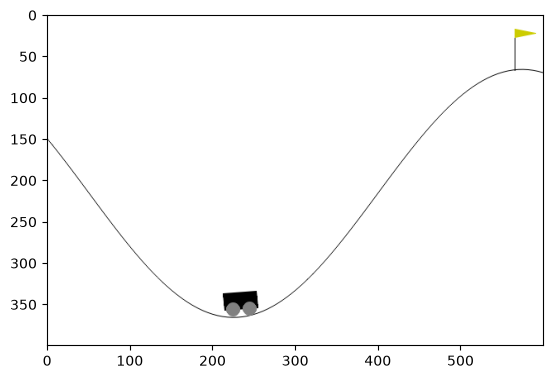

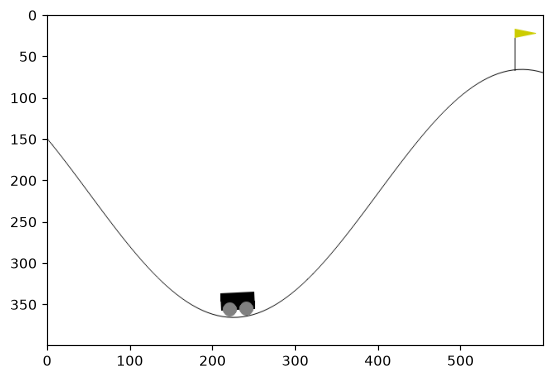

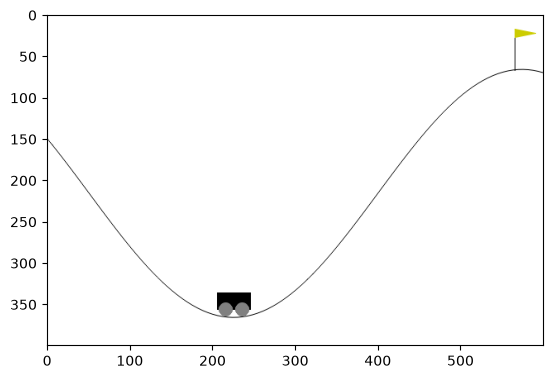

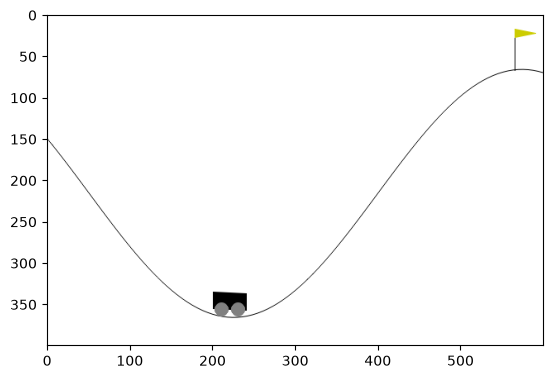

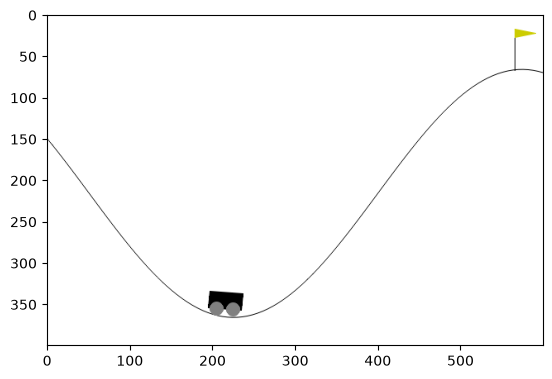

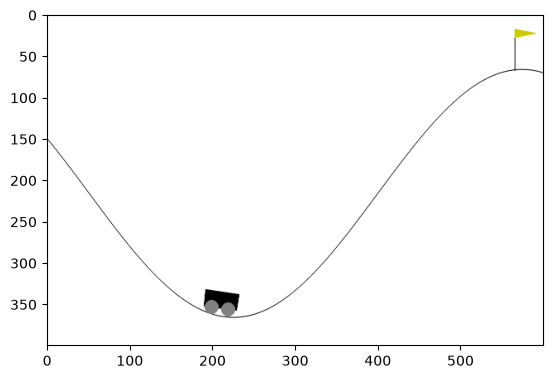

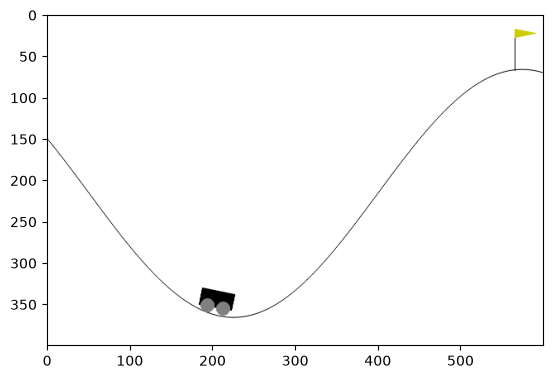

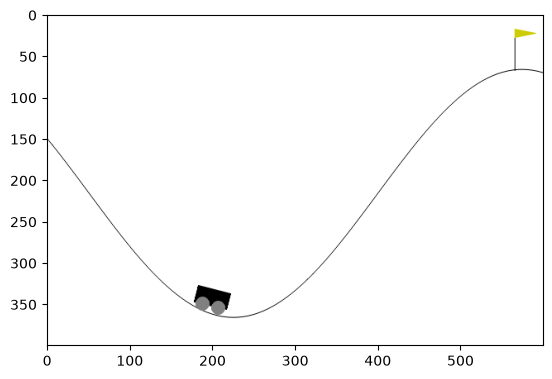

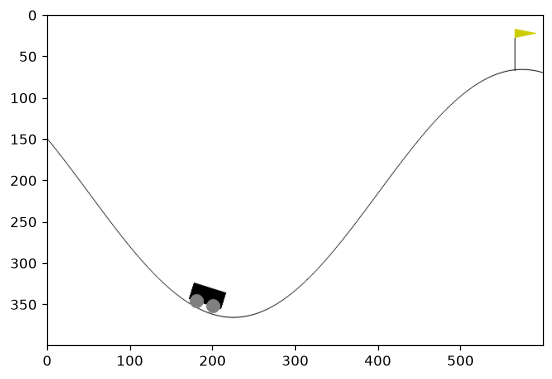

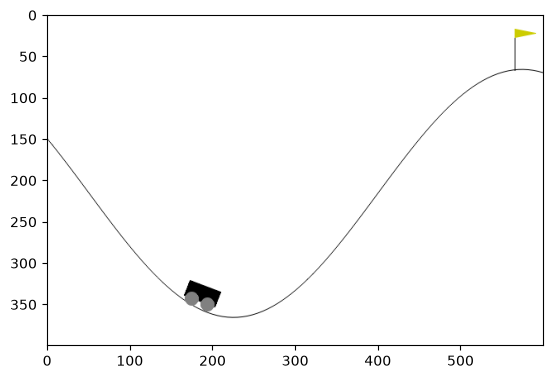

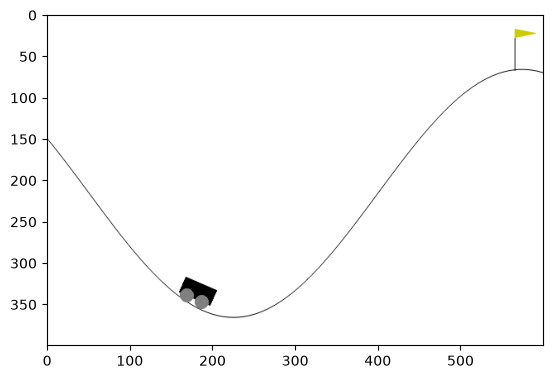

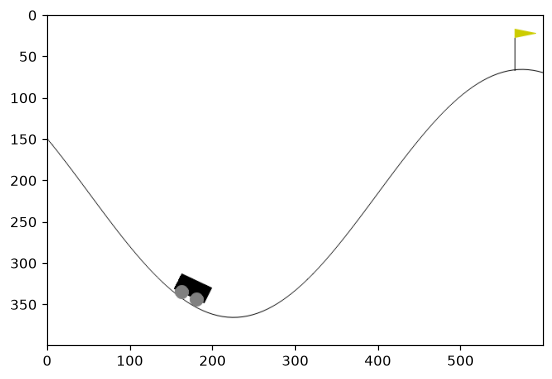

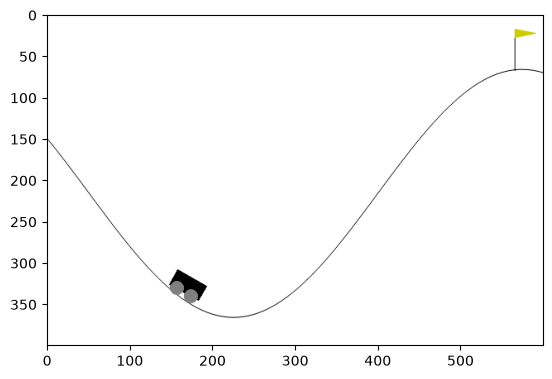

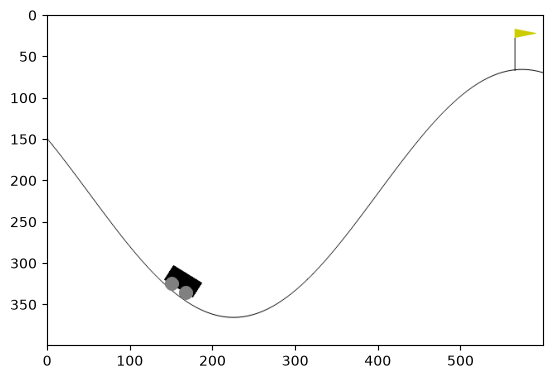

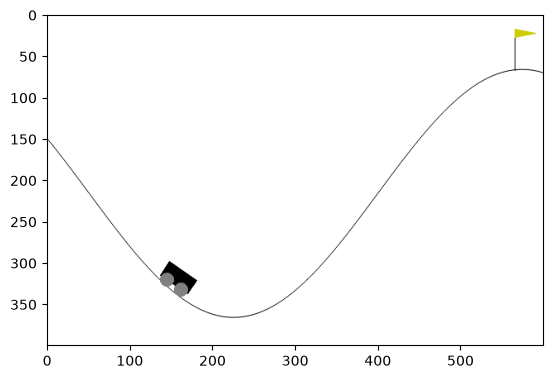

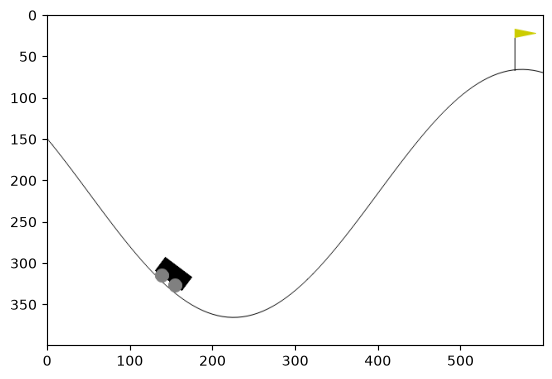

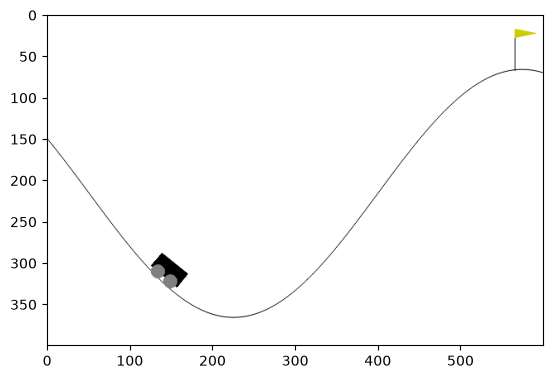

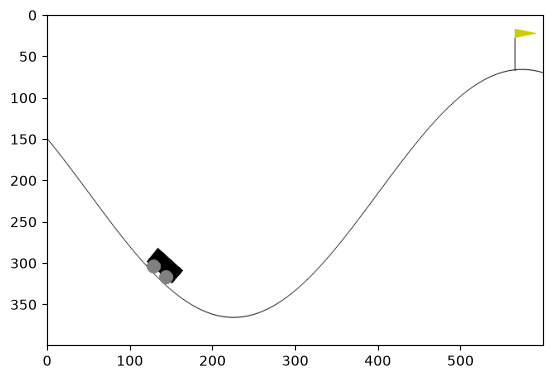

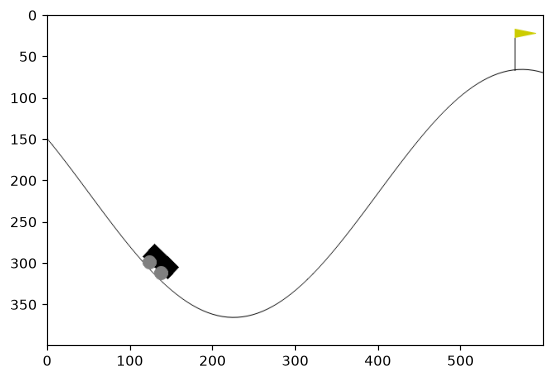

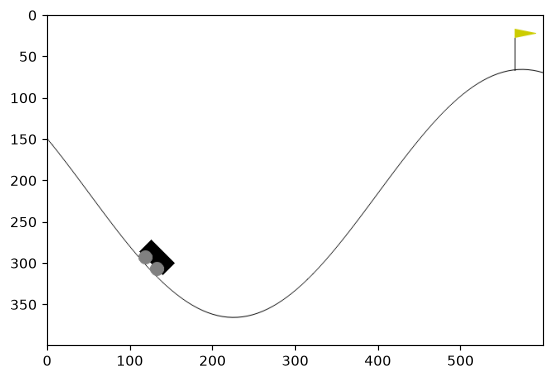

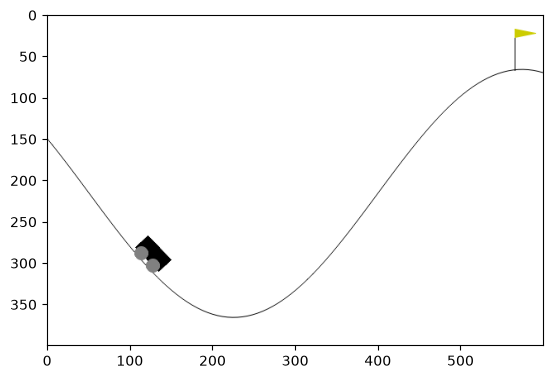

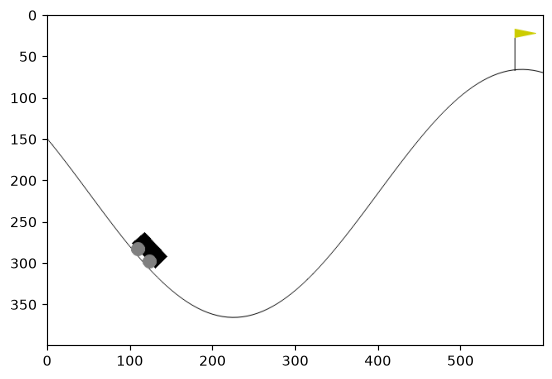

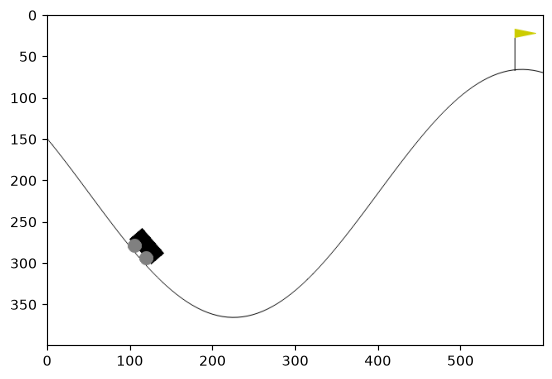

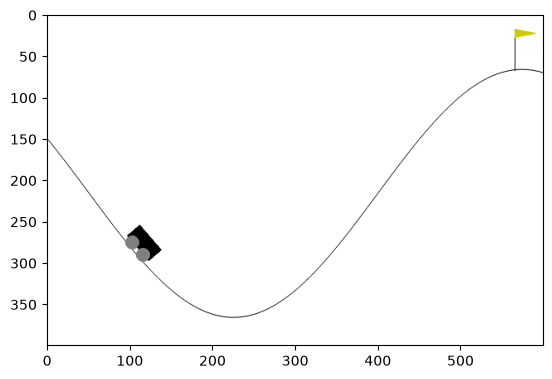

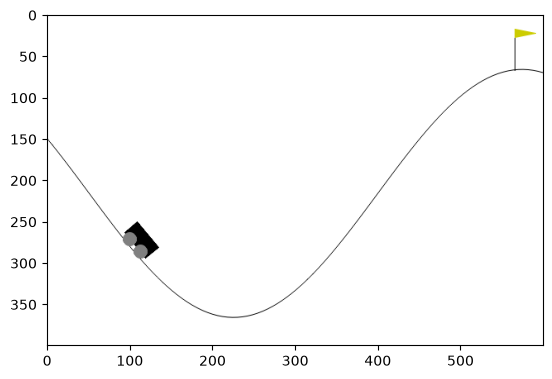

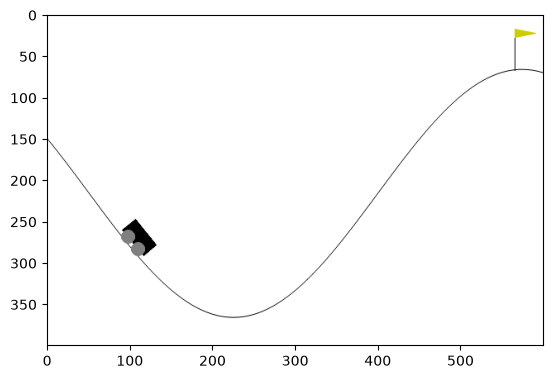

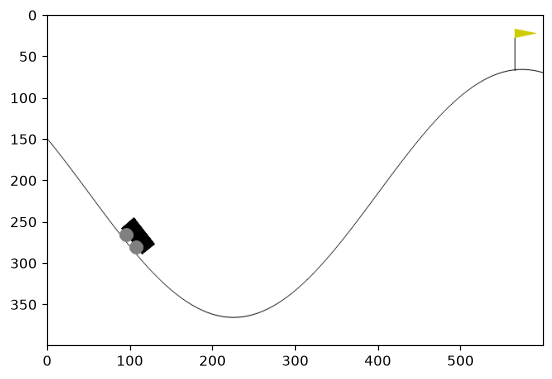

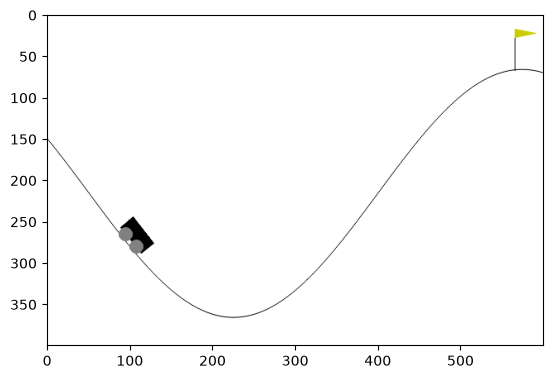

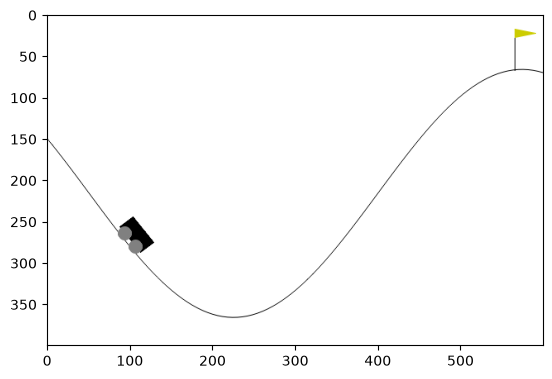

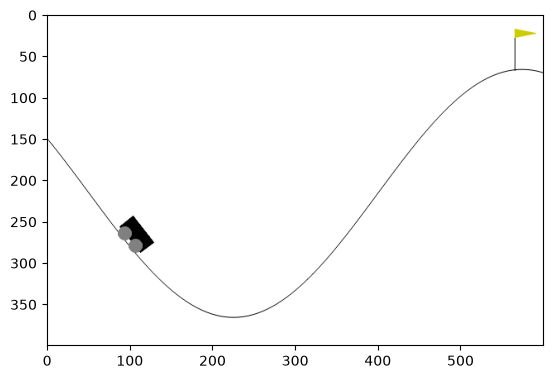

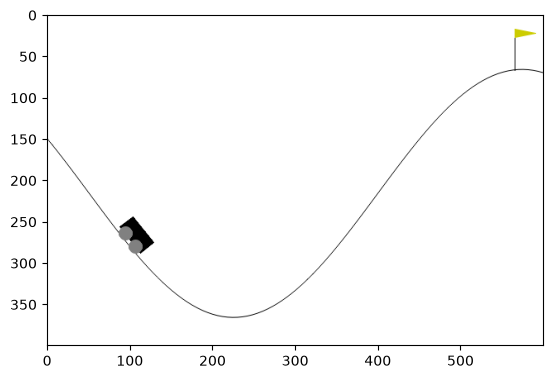

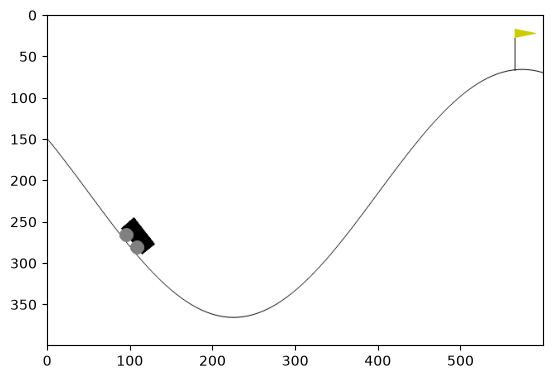

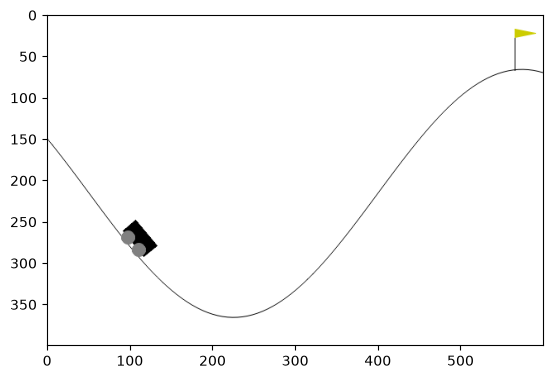

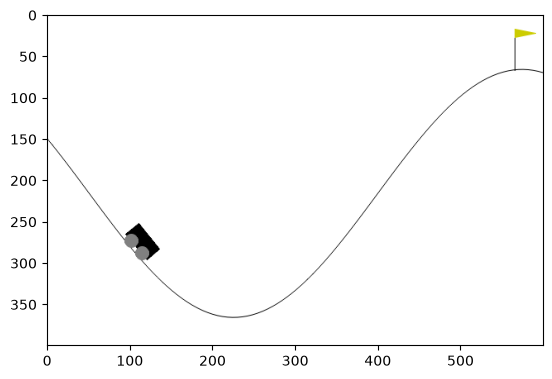

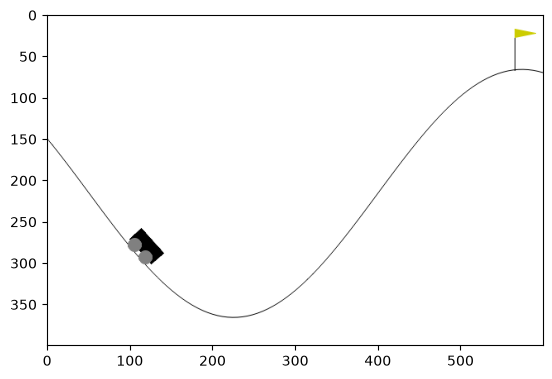

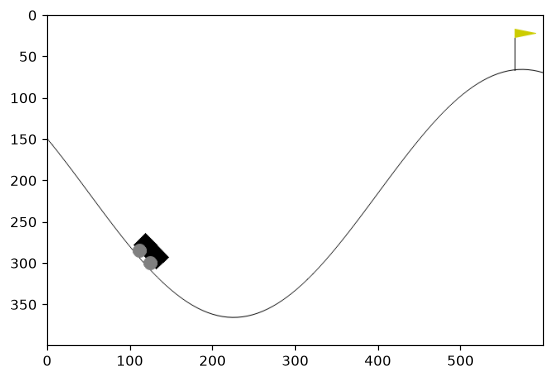

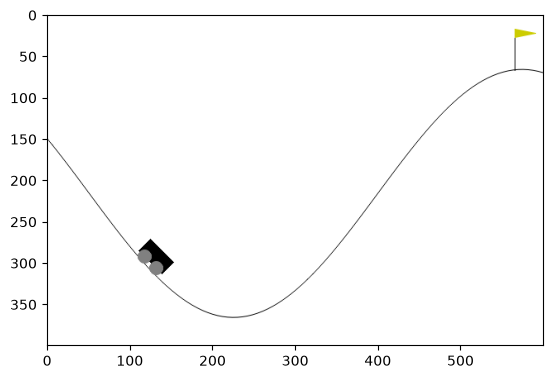

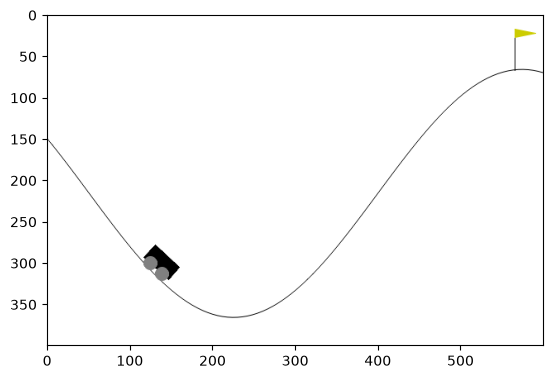

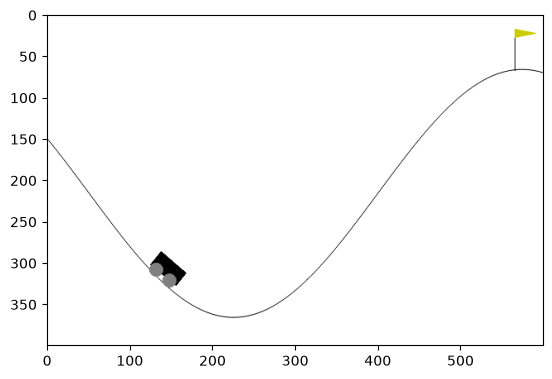

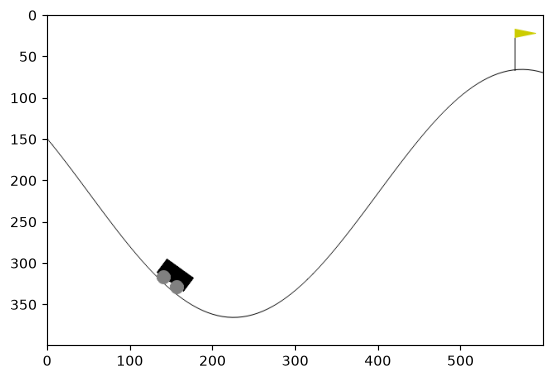

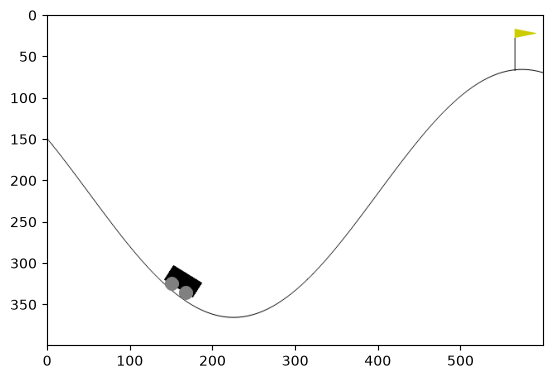

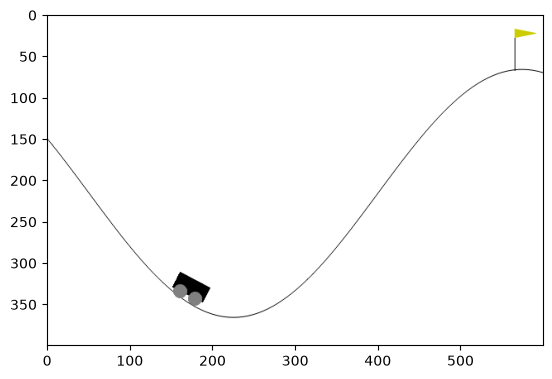

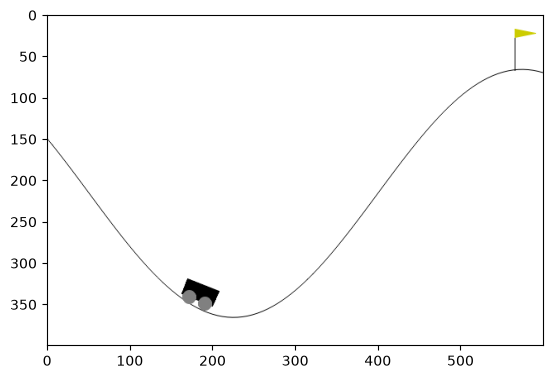

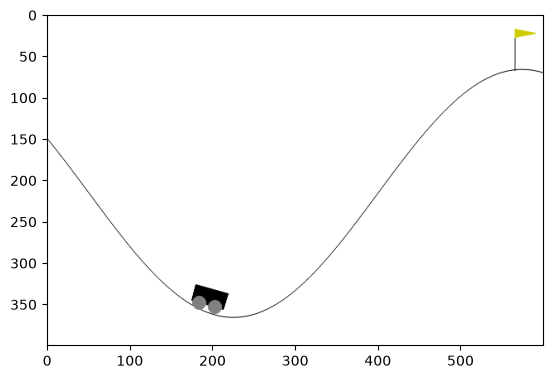

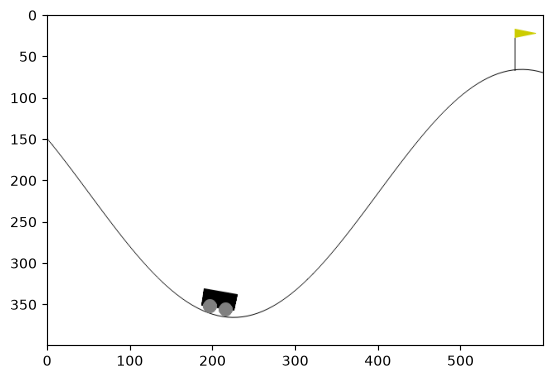

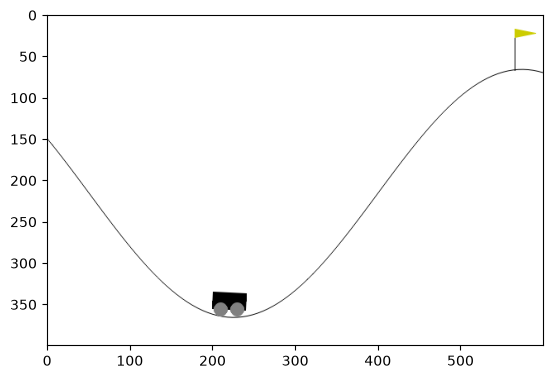

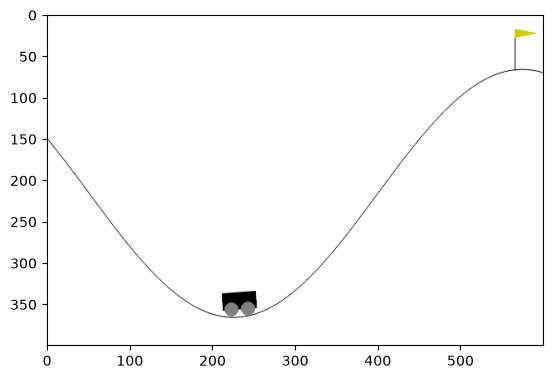

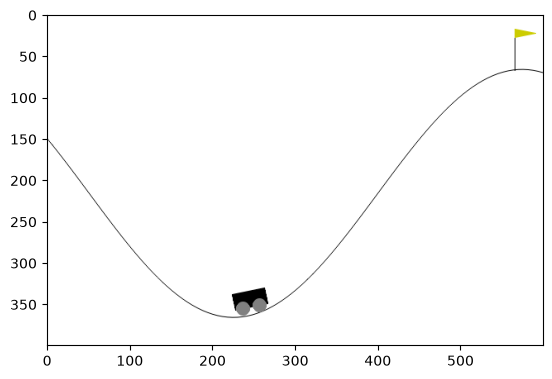

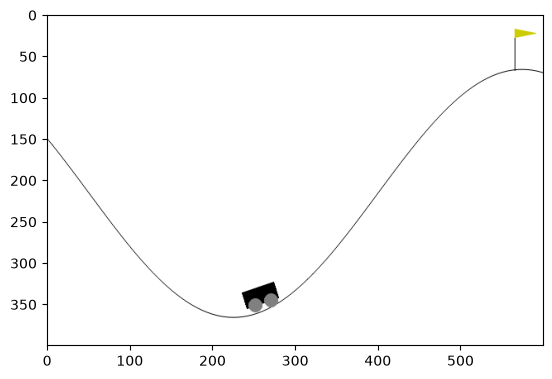

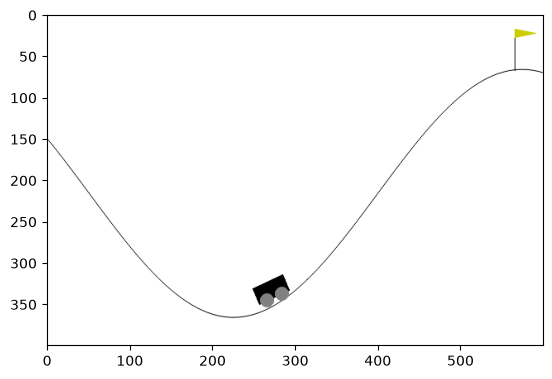

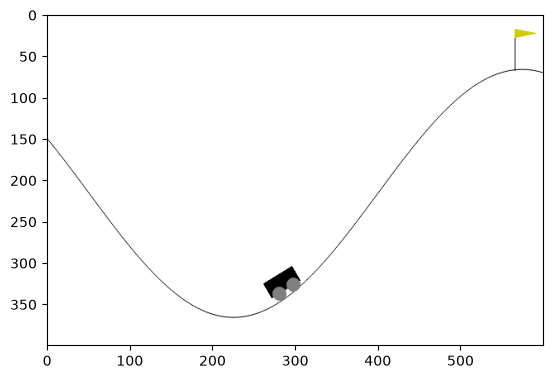

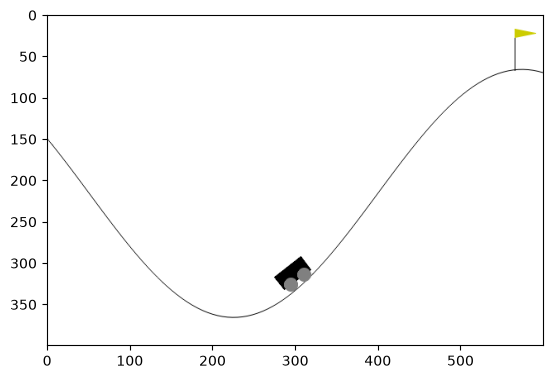

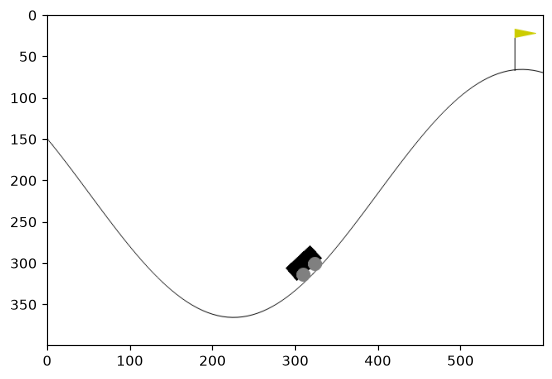

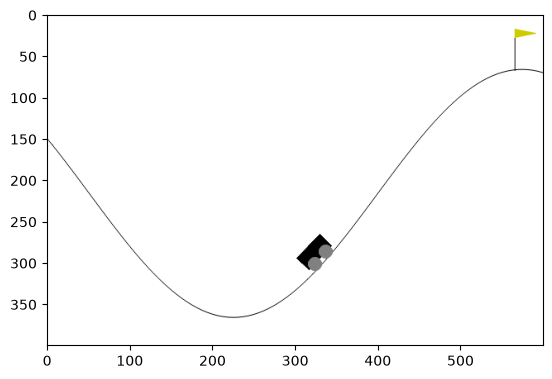

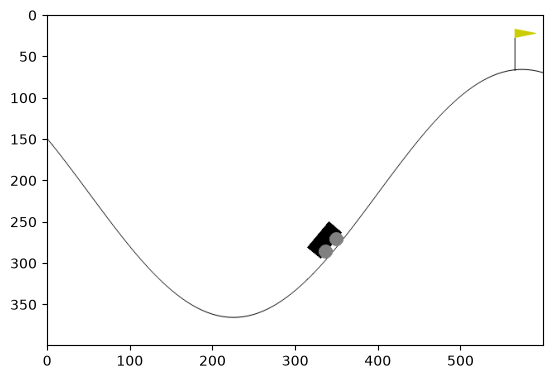

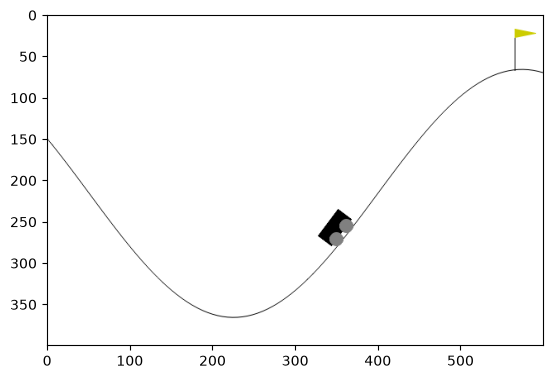

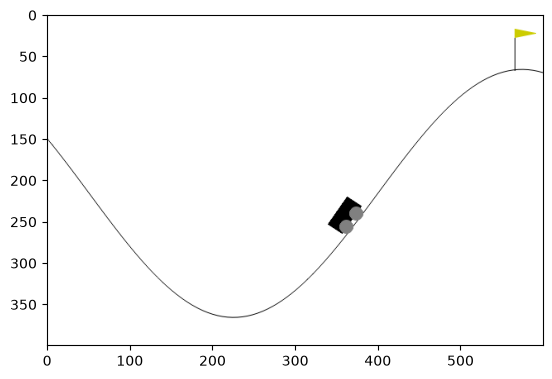

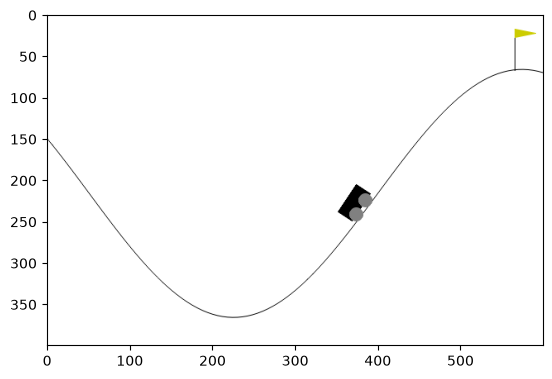

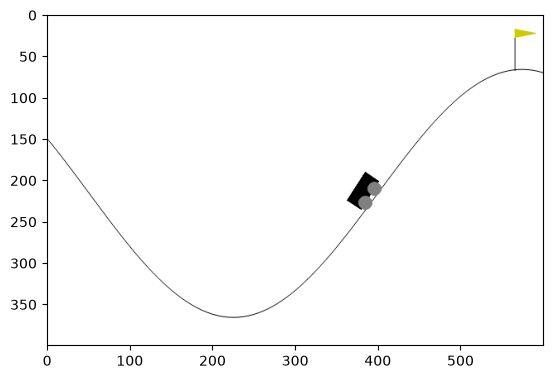

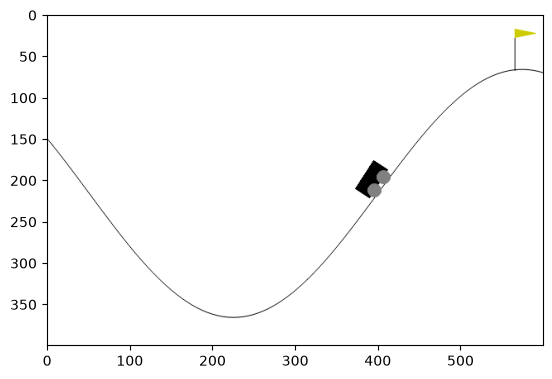

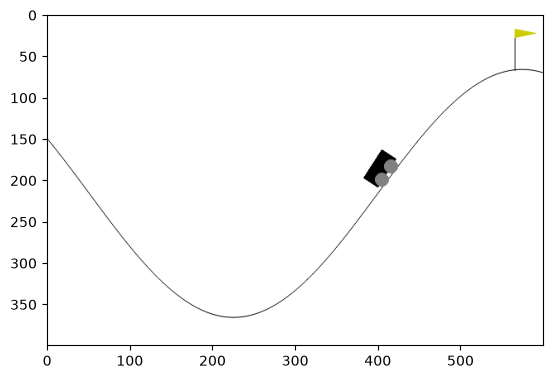

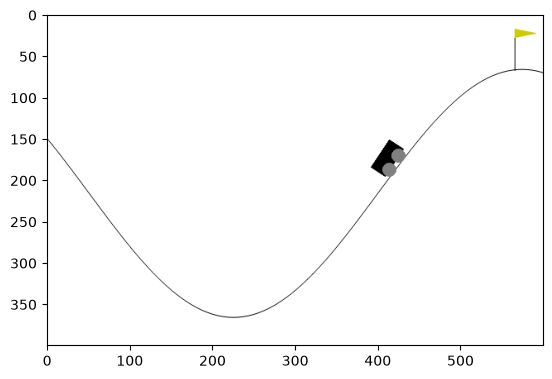

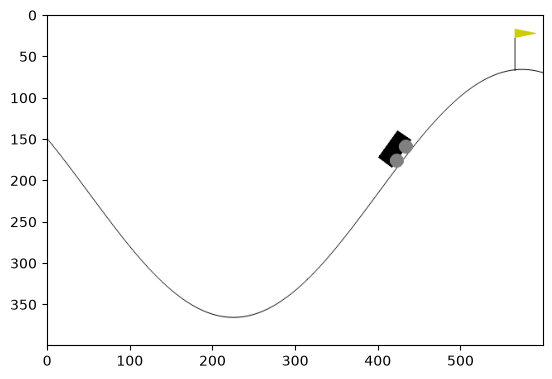

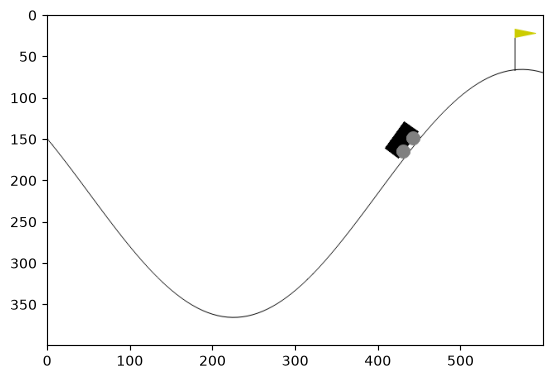

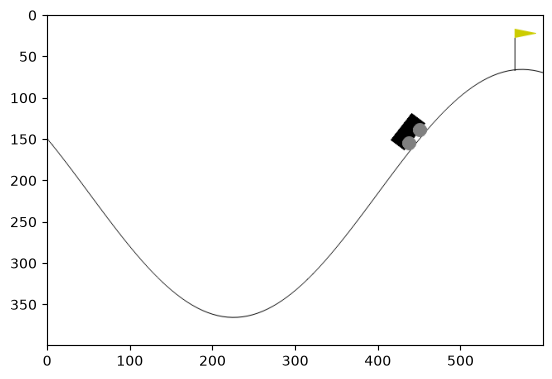

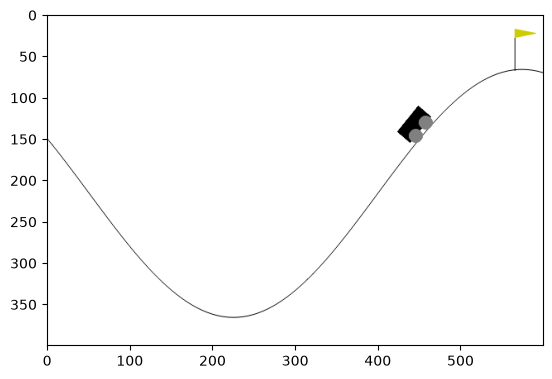

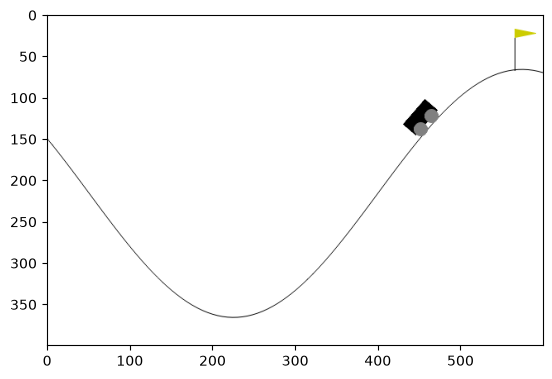

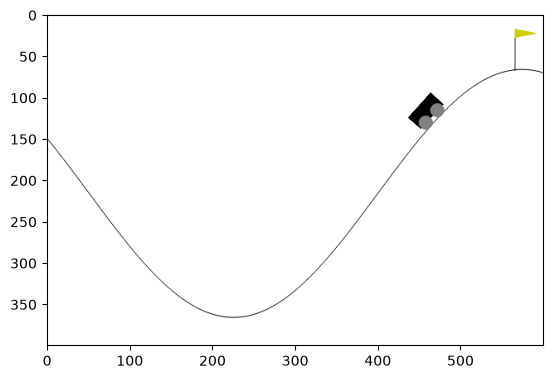

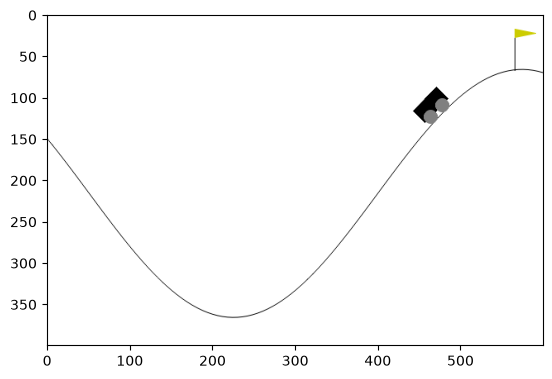

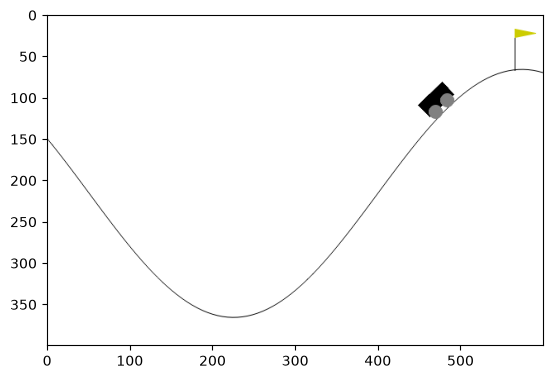

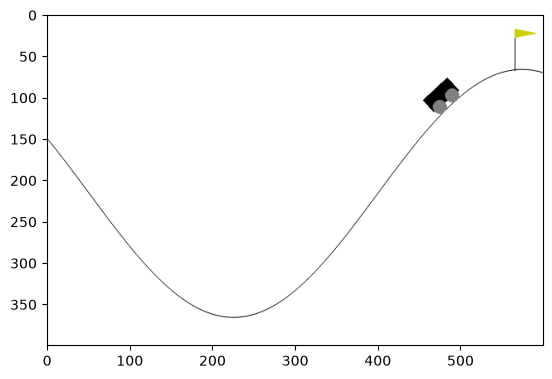

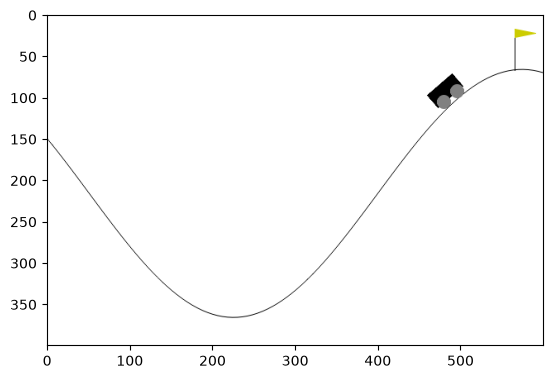

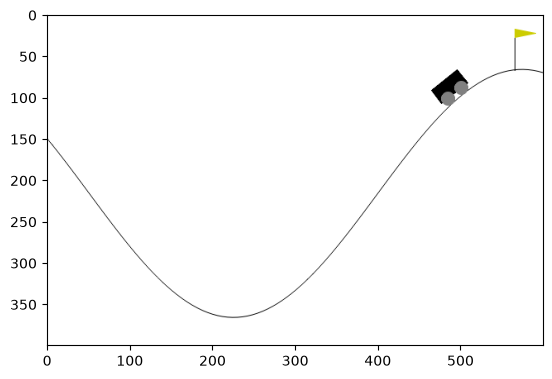

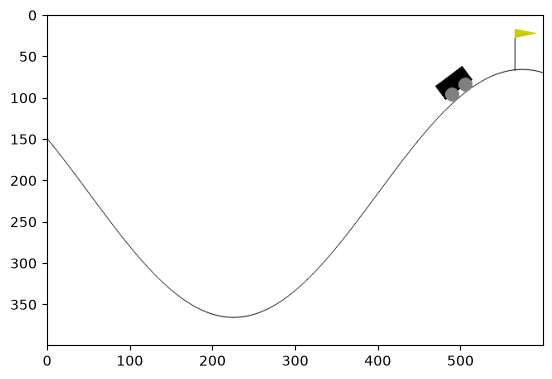

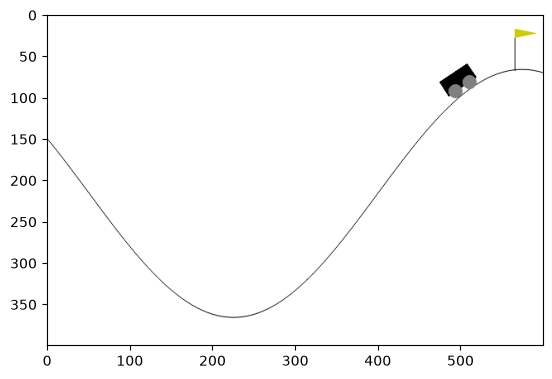

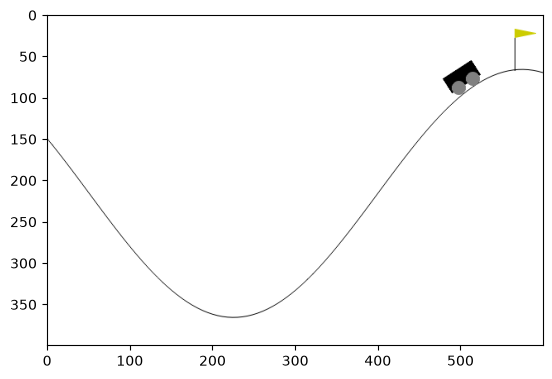

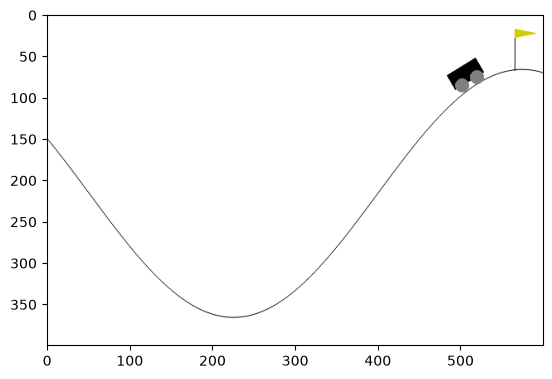

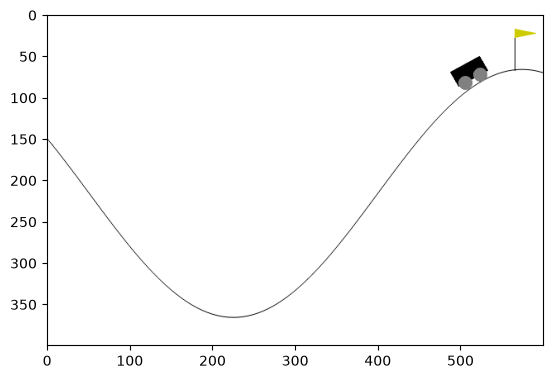

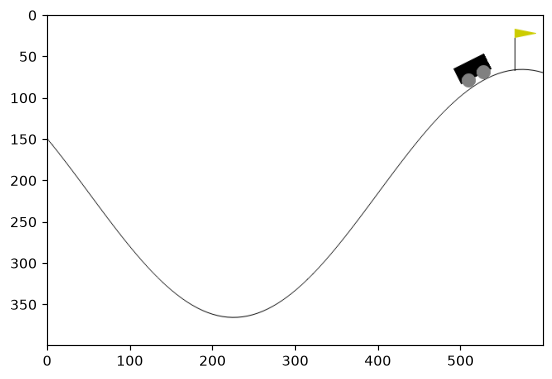

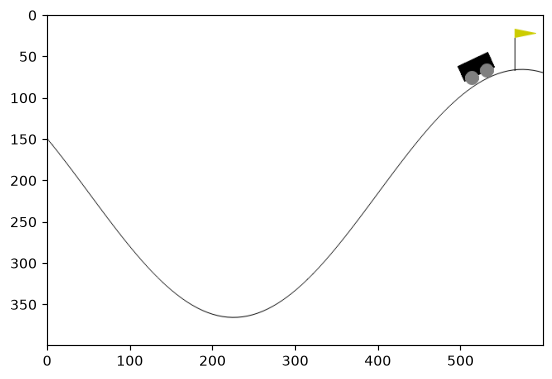

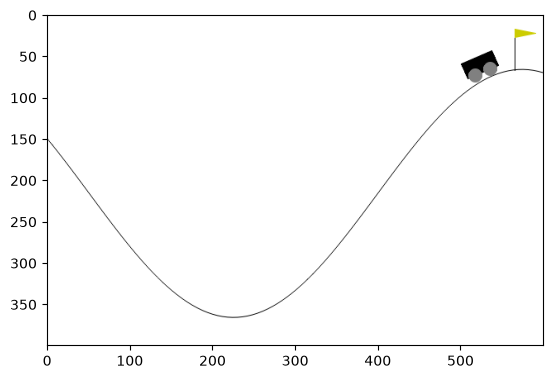

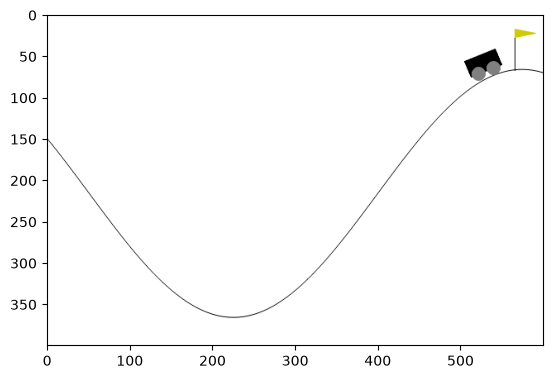

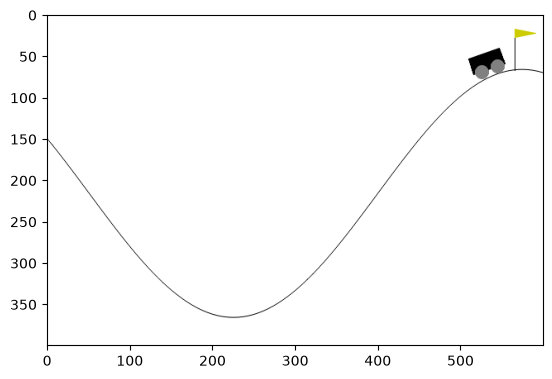

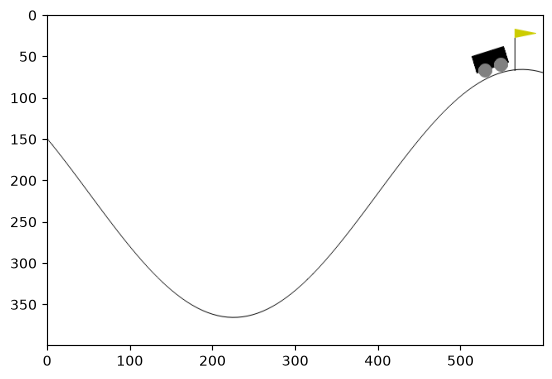

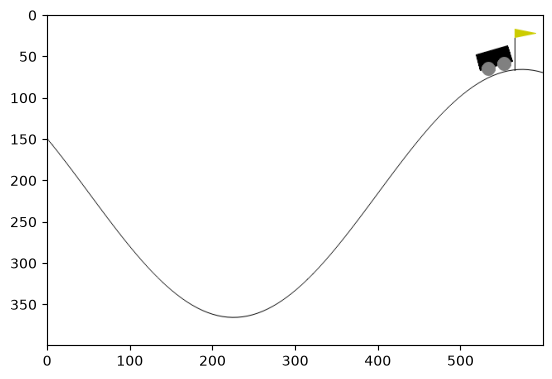

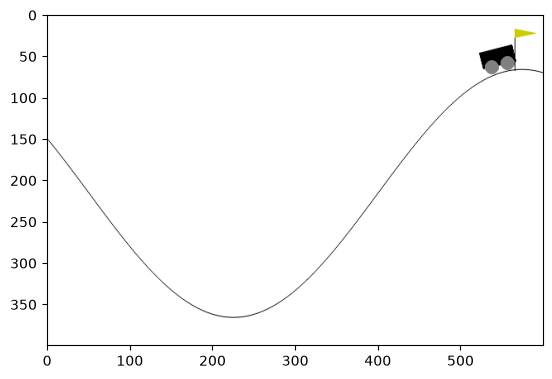

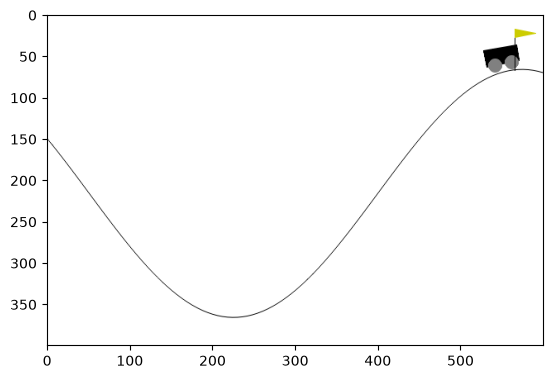

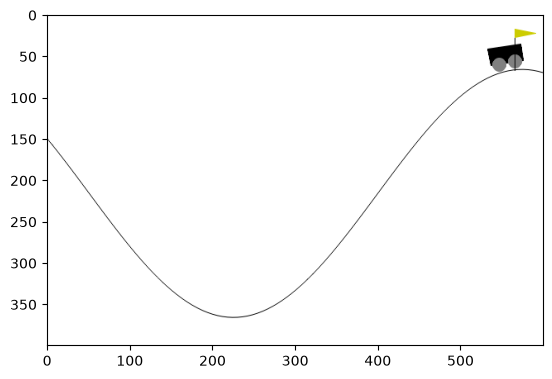

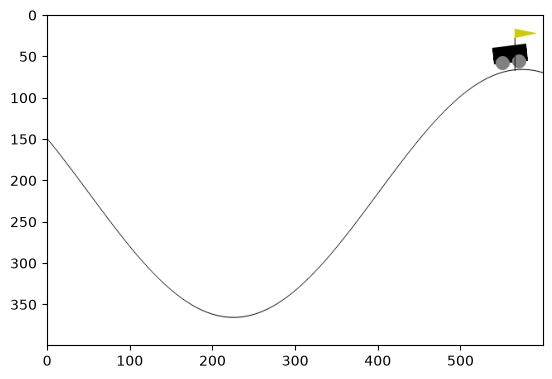

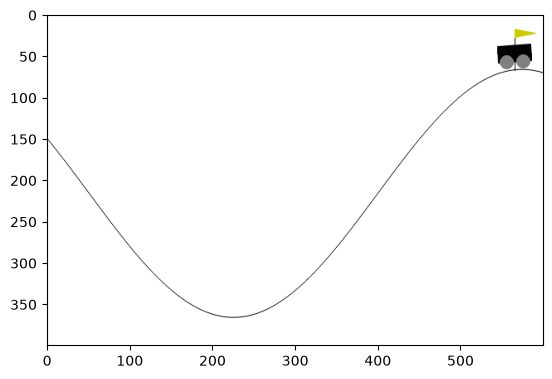

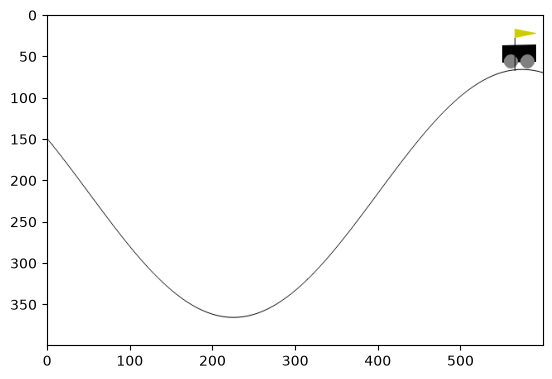

-98.0

In [9]:
import random
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

def observation_to_state(env, obs, states = (40,40)):
    """
    Convert observation from environment into a discrete state.
    
    Parameters
    ----------
    env : gym env
        Reference to the current environment.
    obs : tuple or array 
        An observation for the agent.
    states : tuple, optional
        For each dimension, the number of bins used. The default is (40,40).

    Returns
    -------
    A tuple containing the state corresponding to the observation.

    """    
    ##
    ## your code here
    ##
    obs_high = env.observation_space.high
    obs_low = env.observation_space.low
    dx = (obs_high - obs_low) / states # the width of each bins 
    # the current bin of our car
    s0 = int((obs[0] - obs_low[0])/dx[0]) # the x axis 
    s1 = int((obs[1] - obs_low[1]) /dx[1]) # the y axis 
    return s0, s1


### RL below this line

def choose(env, q, state, epsilon):
    """
    epsilon-greedy action selection. Greedy action selection if epsilon == 0.

    Parameters
    ----------
    env : gym env
        Reference to the current environment
    q : np.array (state_1 x .. x state_n x actions)
        A (n+1) dimensional q table:
            (n state dimensions + 1 action dimension)
            probability of taking an action
    state : tuple
        2-dimensional integer tuple describing the current state of the agent.
    epsilon : float
        Probability of taking a random action.
        If epsilon == 0, we use (max) greedy action selection.
        If epsilon > 0, we choose epsilon-greedy and according to probability

    Returns
    -------
    int
        The chosen action.

    """
    assert len(q.shape)-1 == len(state), "number of state dimensions in "
    "q-table should match dimensions in state parameter"

    s0, s1 = state
    
    if epsilon == 0:
        # return best action (deterministically)
        return np.argmax(q[s0, s1])
    
    if np.random.uniform(0, 1) < epsilon:
        return np.random.choice(env.action_space.n)

    logits = q[s0, s1]    
    logits_exp = np.exp(logits)
    probabilities = logits_exp / sum(logits_exp)
    
    return np.random.choice(env.action_space.n, p = probabilities)


def update_model(model, actions, state, action, reward, nextstate):
    model[(state, action)] = (reward, nextstate)
    
    if state in actions:
        if action not in actions[state]:
            actions[state].append(action)
    else:
        actions[state] = [action]


def select_from_model(model, actions):
    ##
    state = random.choice(list(actions.keys())) # randomly selection the action
    actionset = actions[state]
    action = random.choice(actionset)
    return state, action, model[(state, action)]
    


def qlearn(env, alpha, epsilon, gamma, max_steps,
           num_episodes = 2000, num_states = (40,40)):
    """
    Tabular Q-Learning for gym

    Parameters
    ----------
    env : gym env
        Reference to the current environment
    alpha : float 
        an initial learning rate; reduced for every episode down to a minimum.
    epsilon : float
        a probability for choosing a random action (0 <= epsilon <= 1).
    terminal : list
        a list of terminal states
    gamma : float
        a discount value (0 < gamma < 1).
    num_episodes : int, optional
        Number of episodes to train. The default is 5000.
    num_states : tuple, optional
        Number of states in each observation dimension. The default is (40,40).

    Returns
    -------
    q : array (num_states x num_actions)
        state-action value table.

    """
    q = np.zeros((num_states[0], num_states[1], env.action_space.n))

    # model is an empty dictionary. 
    # It will map from (state, action) -> (reward, nextstate)
    model = dict()
    # actions is an empty dictionary
    # It will map from state -> set of actions
    actions = dict()
    # number of dyna steps
    dynasteps = 5

    avg_reward = 0
    avg_freq = 50
    
    for i in range(num_episodes):
        obs, _ = env.reset()
        total_reward = 0
        eta = max(0.005, alpha * (0.85 ** (i//100)))

        for t in range(max_steps):
            s0, s1 = observation_to_state(env, obs, num_states)
            action = choose(env, q, (s0, s1), epsilon)
            obs, reward, done, truncated, _ = env.step(action)
            total_reward += reward
            avg_reward += reward
            
            s2, s3 = observation_to_state(env, obs, num_states)
            
            q[s0, s1, action] = q[s0, s1, action] + eta * (reward + gamma *  np.max(q[s2,s3]) - q[s0, s1, action])
            
            ## dyna-q part:
            # your code here: update model 
            update_model(model, actions, (s0,s1), action, reward, (s2, s3))

            # execute planning updates
            for j in range(dynasteps):
                # your code: use model to select action 
                # your code: update q-table
                (s4, s5), a, (r, (s6, s7)) = select_from_model(model, actions)
                q[s4, s5, a] = q[s4, s5, a] + eta * (r + gamma * np.max(q[s6, s7] - q[s4, s5, a]))
            
            if done or truncated:
                break

            s0, s1 = s2, s3

        if i % avg_freq == 0:
            avg_reward /= avg_freq
            print('Iteration: %d (Dyna: %d steps) | Average total: %d | Last total: %d.' %(i+1, dynasteps, avg_reward, total_reward))
            avg_reward = 0

    return q, model, actions


def run_policy(env, q, max_steps, num_states = (40,40), render = False):

    obs, _ = env.reset()
    total_reward = 0
    for t in range(max_steps):
        state = observation_to_state(env, obs, num_states)
        action = choose(env, q, state, 0)
        obs, reward, done, truncated, _ = env.step(action)
        if render:
            plt.imshow(env.render())
            plt.show()
            
        total_reward += reward
        if done or truncated:
            break
    
    return total_reward


alpha = 1.0
epsilon = 0.05
gamma = 1.0
max_steps = 200
environment = gym.make('MountainCar-v0', render_mode = "rgb_array")

np.random.seed(0)
num_states = (40,40)
num_episodes = 5000

q, model, actions = qlearn(environment, alpha, epsilon, gamma, max_steps, 
                           num_episodes = num_episodes, num_states = num_states)
scores = [run_policy(environment, q, max_steps, num_states = num_states) for _ in range(100)]
print('Mean score: ', np.mean(scores))

run_policy(environment, q, max_steps, num_states = num_states, render = True)